<a href="https://colab.research.google.com/github/znr6s28ynr-maker/Deep-Learning-with-Python-Experimentation/blob/main/A_Linear_Classifier_in_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Linear Classifiers** find the parameters of a line neatly separating two classes of data

In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


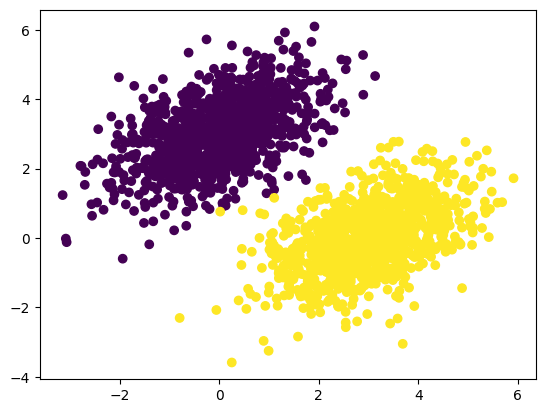

In [12]:
num_samples_per_class = 1000

#generates first class of points: 1000 random points (x,y) with specified mean and covariance matrix (describes shape of point cloud on graph)
#both classes are arrays with shape (1000, 2)
negative_samples = np.random.multivariate_normal(
    mean=[0,3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

#generating second class
positive_samples = np.random.multivariate_normal(
    mean=[3,0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

#stacking arrays
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

#generating targets labels (array of 0s and 1s of shape (2000, 1)
targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        np.ones((num_samples_per_class, 1), dtype="float32"),
    )
)

#plotting array of generated points
plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

In [16]:
#creating linear classifier to separate blobs of points

#creating variables W and b, initials with random values (for W) and zeros (for b)
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

#forward pass function
def model(inputs, W, b):
  return tf.matmul(inputs, W) + b

#loss function (mean squared)
def mean_squared_error(targets, predictions):
  per_sample_losses = tf.square(targets - predictions) #will be tensor with same shape as targets and predictions, with per-sample loss scores
  return tf.reduce_mean(per_sample_losses) #averaging all into a single scalar loss (mean)

Loss at step 0: 0.1841
Loss at step 1: 0.1032
Loss at step 2: 0.0887
Loss at step 3: 0.0822
Loss at step 4: 0.0772
Loss at step 5: 0.0726
Loss at step 6: 0.0684
Loss at step 7: 0.0646
Loss at step 8: 0.0612
Loss at step 9: 0.0580
Loss at step 10: 0.0551
Loss at step 11: 0.0525
Loss at step 12: 0.0501
Loss at step 13: 0.0479
Loss at step 14: 0.0459
Loss at step 15: 0.0441
Loss at step 16: 0.0424
Loss at step 17: 0.0409
Loss at step 18: 0.0395
Loss at step 19: 0.0382
Loss at step 20: 0.0371
Loss at step 21: 0.0360
Loss at step 22: 0.0350
Loss at step 23: 0.0342
Loss at step 24: 0.0333
Loss at step 25: 0.0326
Loss at step 26: 0.0319
Loss at step 27: 0.0313
Loss at step 28: 0.0308
Loss at step 29: 0.0303
Loss at step 30: 0.0298
Loss at step 31: 0.0294
Loss at step 32: 0.0290
Loss at step 33: 0.0286
Loss at step 34: 0.0283
Loss at step 35: 0.0280
Loss at step 36: 0.0277
Loss at step 37: 0.0275
Loss at step 38: 0.0273
Loss at step 39: 0.0271


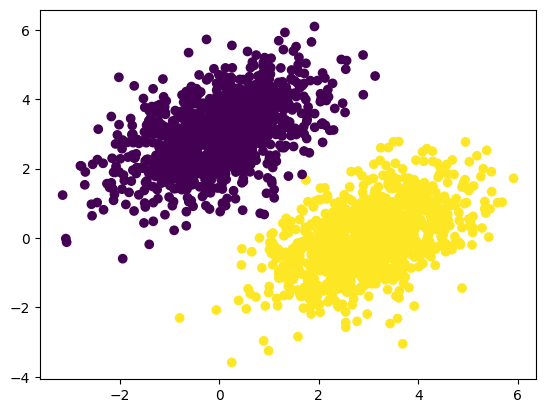

In [17]:
#training the model

learning_rate = 0.1
@tf.function(jit_compile=True) #speeds up function
def training_step(inputs, targets, W, b):

  #forward pass inside gradient tape scope
  with tf.GradientTape() as tape:
    predictions = model(inputs, W, b)
    loss = mean_squared_error(predictions, targets)
  grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
  W.assign_sub(grad_loss_wrt_W * learning_rate)
  b.assign_sub(grad_loss_wrt_b * learning_rate)
  return loss

#batch training loop
for step in range(40):
  loss = training_step(inputs, targets, W, b)
  print(f"Loss at step {step}: {loss:.4f}")

#plotting predictions
predictions = model(inputs, W, b)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()



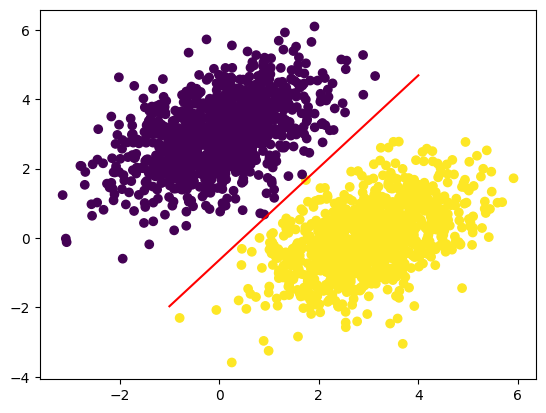

In [19]:
#plotting line that divides classes according to the prediction model

x = np.linspace(-1, 4, 100) #generates 100 evenly spaced numbers between -1 and 4 for x
y = -W[0] / W[1] * x + (0.5 - b) / W[1] #equation of line
plt.plot(x, y, "-r") # "-r" is the color red
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5) #plots models predictions